# Visualizing Categorical Distributions (Pandas Version)

Data come in many forms that are not numerical. Data can also be categorical, meaning they describe group membership or labels rather than numeric values.

Examples of categorical variables include:
- Ice cream flavors
- Sports teams
- Movie genres
- Survey responses

In this notebook, we will use **pandas** instead of the `datascience` package to explore and visualize categorical distributions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
path_data = '../../../assets/data/'
%matplotlib inline
plt.style.use('fivethirtyeight')
np.set_printoptions(threshold=50)

## Ice Cream Example

In [11]:
icecream = pd.DataFrame({
    'Flavor': ['Chocolate', 'Strawberry', 'Vanilla'],
    'Number of Cartons': [16, 5, 9]
})
icecream

,Flavor,Number of Cartons
0,Chocolate,16
1,Strawberry,5
2,Vanilla,9


The *values* of the categorical variable "flavor" are chocolate, strawberry, and vanilla. 

Each of the cartons had exactly one of the three flavors. In a *distribution*, each individual belongs to exactly one category and thus has exactly one value. So we have a distribution of flavors.

The DataFrame shows the number of cartons of each flavor. We call this a *distribution (or Frequency) table*. A distribution table shows all the values of the variable along with the frequency of each one.

## Bar Chart
The bar chart is a familiar way of visualizing categorical distributions. It displays a bar for each category. The bars are equally spaced and equally wide. The length of each bar is proportional to the frequency of the corresponding category.

We will draw bar charts with horizontal bars because it's easier to label the bars that way. The Table method is therefore called `barh`. It takes two arguments: the first is the column label of the categories, and the second is the column label of the frequencies.## Bar Chart

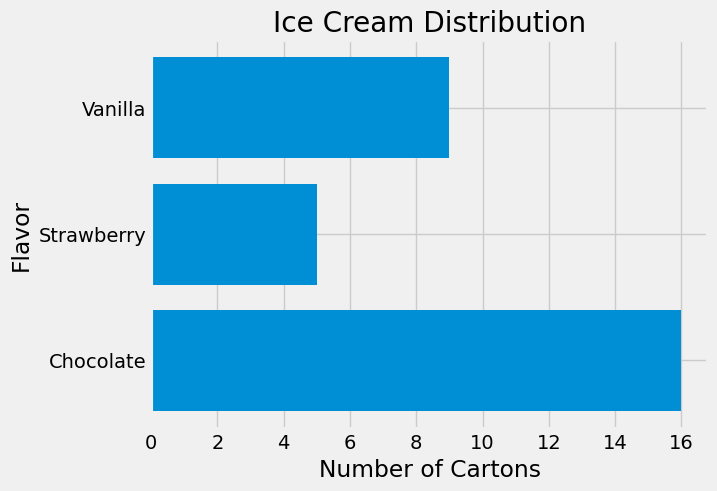

In [12]:
plt.figure()
plt.barh(icecream['Flavor'], icecream['Number of Cartons'])
plt.xlabel('Number of Cartons')
plt.ylabel('Flavor')
plt.title('Ice Cream Distribution')
plt.show()

## Design Aspects of Bar Charts
Apart from purely visual differences, there is an important fundamental distinction between bar charts and the two graphs that we saw in the previous sections. Those were the scatter plot and the line plot, both of which display two quantitative variables – the variables on both axes are quantitative. In contrast, the bar chart has categories on one axis and numerical quantities on the other.

This has consequences for the chart. First, the width of each bar and the space between consecutive bars is entirely up to the person who is producing the graph, or to the program being used to produce it. Python made those choices for us. If you were to draw the bar graph by hand, you could make completely different choices and still have a perfectly correct bar graph, provided you drew all the bars with the same width and kept all the spaces the same.

Most importantly, the bars can be drawn in any order. The categories "chocolate," "vanilla," and "strawberry" have no universal rank order, unlike for example the numbers 5, 7, and 10.

This means that we can draw a bar chart that is easier to interpret, by rearranging the bars in decreasing order. To do this, we first rearrange the rows of `icecream` in decreasing order of `Number of Cartons`, and then draw the bar chart.

## Sorting for Better Visualization

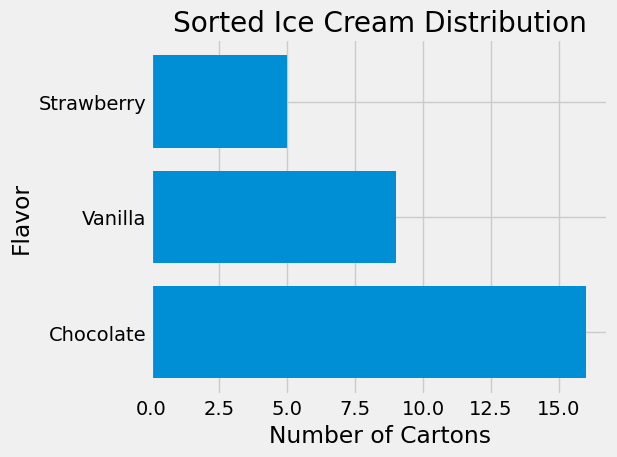

In [38]:
icecream_sorted = icecream.sort_values(by='Number of Cartons', ascending=False)

plt.figure()
plt.barh(icecream_sorted['Flavor'], icecream_sorted['Number of Cartons'])
plt.xlabel('Number of Cartons')
plt.ylabel('Flavor')
plt.title('Sorted Ice Cream Distribution')
plt.tight_layout()
plt.show()

Sorting categories often makes charts easier to interpret.

## Grouping Categorical Data
To construct the DataFrame `icecream`, someone had to look at all 30 cartons of ice-cream and count the number of each flavor. But if our table does not already include frequencies, we have to compute the frequencies before we can draw a bar chart. Here is an example where this is necessary.

The DataFrame `top` consists of U.S.A.'s top grossing movies of all time, as of 2017. The first column contains the title of the movie; *Star Wars: The Force Awakens* has the top rank, with a box office gross amount of more than 900 million dollars in the United States. The second column contains the name of the studio that produced the movie. The third contains the domestic box office gross in dollars, and the fourth contains the  gross amount that would have been earned from ticket sales at 2016 prices. The fifth contains the year in which the movie was released. 

There are 200 movies on the list. Here are the top ten according to the gross receipts adjusted for inflation.

In [15]:
# Load movie dataset

top = pd.read_csv(path_data + 'top_movies_2017.csv')
top.head(10)

,Title,Studio,Gross,Gross (Adjusted),Year
0,Gone with the Wind,MGM,198676459,1796176700,1939
1,Star Wars,Fox,460998007,1583483200,1977
2,The Sound of Music,Fox,158671368,1266072700,1965
3,E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
4,Titanic,Paramount,658672302,1204368000,1997
5,The Ten Commandments,Paramount,65500000,1164590000,1956
6,Jaws,Universal,260000000,1138620700,1975
7,Doctor Zhivago,MGM,111721910,1103564200,1965
8,The Exorcist,Warner Brothers,232906145,983226600,1973
9,Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


The studios MGM, Fox, Universal, and Paramount show up more than once in the top ten. Which studios will appear most frequently if we look among all 200 rows?

To figure this out, first notice that all we need is a DataFrame with the movies and the studios; the other information is unnecessary.

### A small wrinkle:
In the second line you will notive two different mthods
- `.value_counts()` looks at the studio column, finds all the different studios that appear and counts how many times they appar.
- `reset_index()` makes sure we have a real DataFrame where the first row has index 0.

In [ ]:
movies_and_studios = top[['Title','Studio']]
studio_counts = movies_and_studios['Studio'].value_counts().reset_index()
studio_counts

,Studio,count
0,Buena Vista,35
1,Warner Brothers,29
2,Paramount,25
3,Fox,24
4,Universal,23
5,Disney,11
6,Columbia,9
7,MGM,7
8,United Artists,6
9,Newline,5


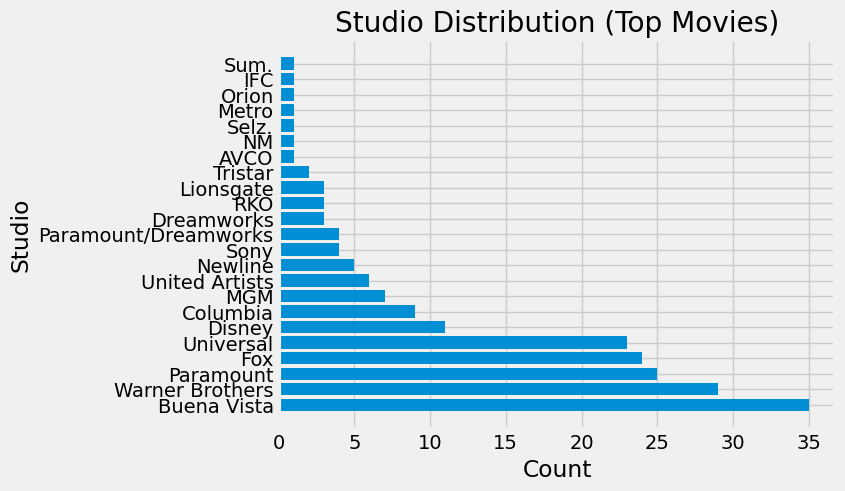

In [19]:
studio_sorted = studio_counts.sort_values(by='count', ascending=False)
plt.figure()
plt.barh(studio_sorted['Studio'], studio_sorted['count'])
plt.xlabel('Count')
plt.ylabel('Studio')
plt.title('Studio Distribution (Top Movies)')
plt.show()

Buena Vista and Warner Brothers are the most common studios among the top 200 movies. Warner Brothers produces the Harry Potter movies and Buena Vista produces Star Wars. 

## Towards Quantitative Variables

Though years are numerical, we could treat the year of release as a categorical variable and plot its distribution. That is, for every year we could find how many movies were released that year, and then draw the bar chart of that distribution.

Let's do that and just look at the 10 earliest years in the distribution.

In [8]:
movies_and_years = top[['Title','Year']]
year_counts = movies_and_years['Year'].value_counts().sort_index().reset_index()
year_counts.columns = ['Year','count']
year_counts.head()

,Year,count
0,1921,1
1,1937,1
2,1939,1
3,1940,1
4,1941,2


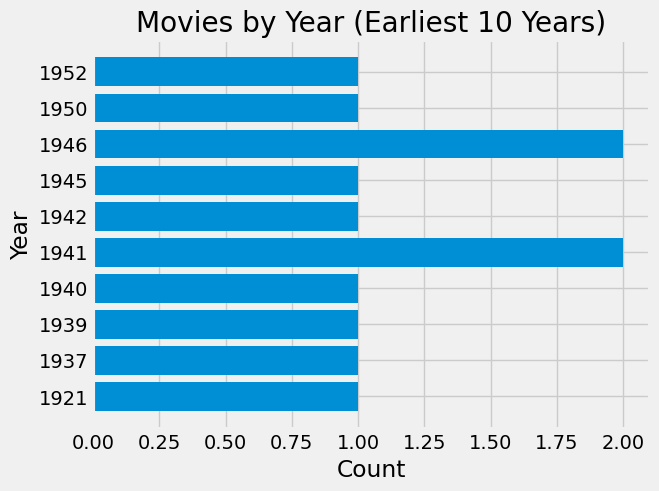

In [41]:
plt.figure()
plt.barh(year_counts.head(10)['Year'].astype(str), year_counts.head(10)['count'])
plt.xlabel('Count')
plt.ylabel('Year')
plt.title('Movies by Year (Earliest 10 Years)')
plt.show()

 That is important here because years have a chronological order that has to be maintained. But there is something disquieting about this bar chart. The bars at 1921 and 1937 are just as far apart from each other as the bars at 1937 and 1939. The bar chart doesn't show that none of the 200 movies were released in the years 1922 through 1936, nor in 1938. Such inconsistencies and omissions make the distribution in the early years hard to understand based on this visualization.

The distribution of a categorical variable can be displayed using a bar chart. But if the variable is not categorical but quantitative, then the numerical relations between its values have to be taken into account when we create visualizations. That is the topic of the next section.